<a href="https://colab.research.google.com/github/rajeshxdatascience/spamshield-ai/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
import pandas as pd
import numpy as np

In [138]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [139]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4049,ham,Ok ok take care. I can understand.,NaN,NaN,NaN
1931,ham,What pa tell me.. I went to bath:-),NaN,NaN,NaN
1711,ham,I got your back! Do you have any dislikes in bed?,NaN,NaN,NaN
4603,ham,THANX 4 PUTTIN DA FONE DOWN ON ME!!,NaN,NaN,NaN
1276,ham,Can do lor...,NaN,NaN,NaN


In [140]:
df.shape

(5572, 5)

In [141]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# 1. Data cleaning

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [143]:
# drop last 3 cols
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [144]:
df.sample(5)

,v1,v2
3007,spam,"Loan for any purpose å£500 - å£75,000. Homeown..."
5209,ham,"I know you are thinkin malaria. But relax, chi..."
1730,ham,Doing project w frens lor.
3308,ham,Okie Ì_ wan meet at bishan? Cos me at bishan n...
3336,ham,I AM AT THE GAS STATION. GO THERE.


In [145]:
# Renaming the cols
df = df.rename(columns={'v1':'target','v2':'text'})

In [146]:
df.sample(5)

,target,text
2178,ham,"I don,t think so. You don't need to be going o..."
3634,ham,It's not that you make me cry. It's just that ...
2580,spam,U are subscribed to the best Mobile Content Se...
507,ham,You should know now. So how's anthony. Are you...
789,ham,Gud mrng dear hav a nice day


In [147]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [148]:
df['target'] = encoder.fit_transform(df['target'])

In [149]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [150]:
# missing values
df.isnull().sum()

,0
target,0
text,0


In [151]:
# check for duplicates
df.duplicated().sum()

np.int64(403)

In [152]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df.shape

(5169, 2)

# EDA

In [155]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [156]:
df['target'].value_counts()

,count
target,
0,4516
1,653


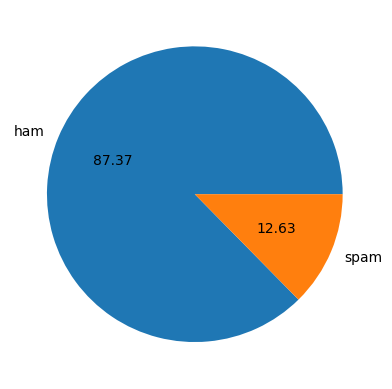

In [157]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [158]:
# Data is imbalanced

In [159]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [160]:
df['num_characters'] = df['text'].apply(len)

In [161]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [162]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [163]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [164]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [165]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [166]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [167]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [168]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [169]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

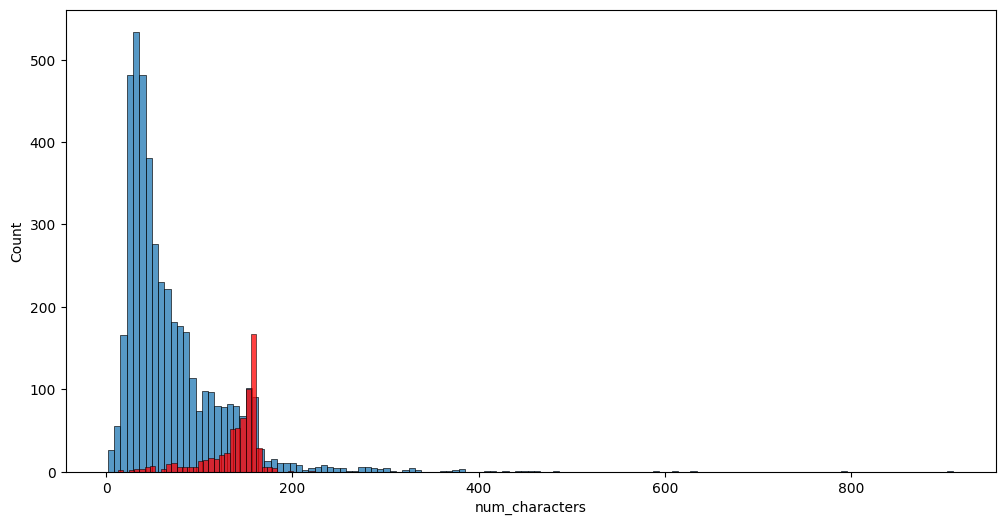

In [170]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

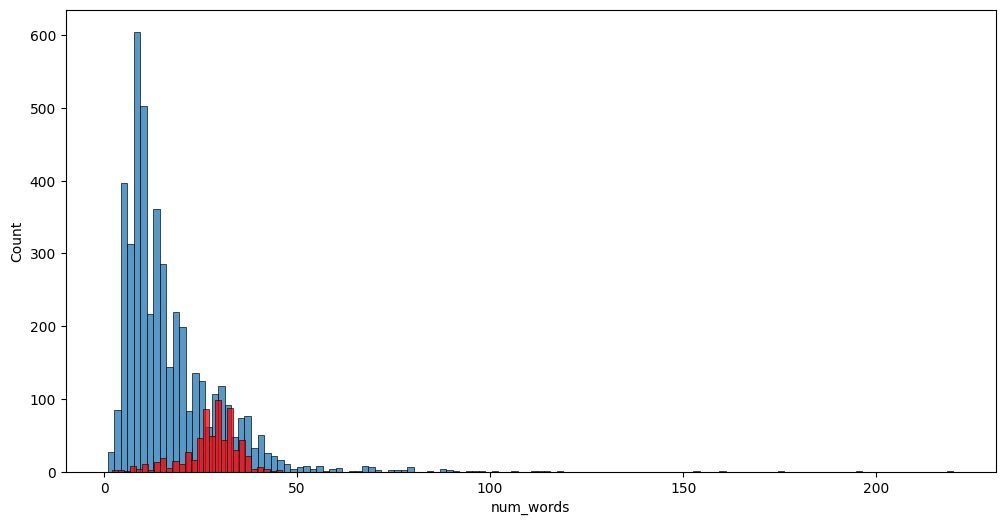

In [171]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

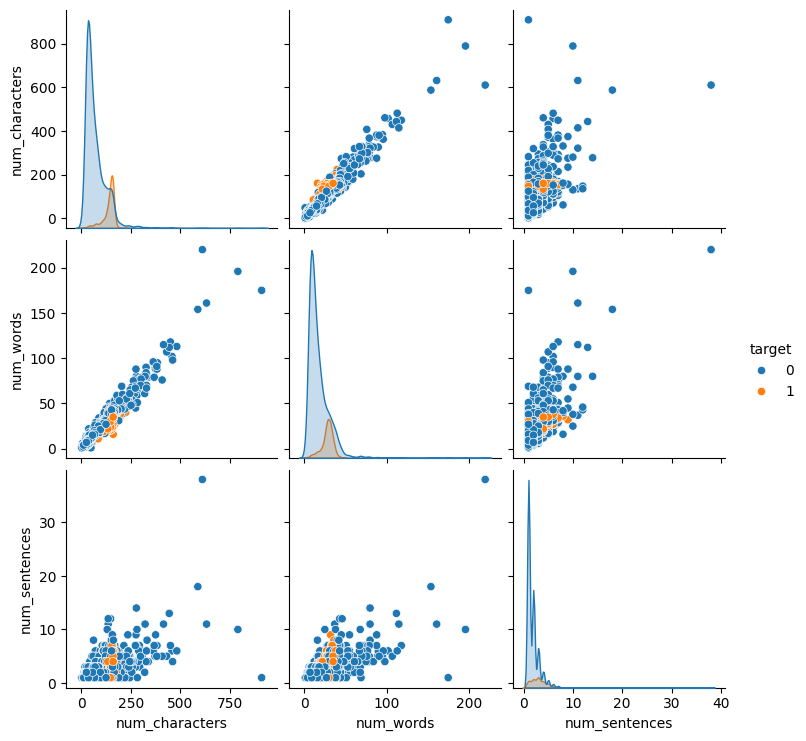

In [172]:
sns.pairplot(df,hue='target')

In [173]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


<Axes: >

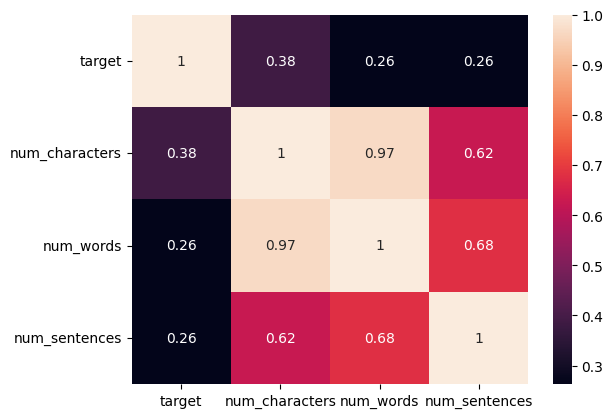

In [174]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

# 3. Data Preprocessing


* Lower case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming



In [175]:
def transform_text(text):

  text = text.lower()

  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [176]:
from nltk.corpus import stopwords

stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [177]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [178]:
# transform_text('I loved the YT lectures on Machine Learning. How about you?')

In [179]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
ps.stem('loving')

'love'

In [180]:
df['transformed_text'] = df['text'].apply(transform_text)

In [181]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [182]:
from wordcloud import WordCloud

wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [183]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

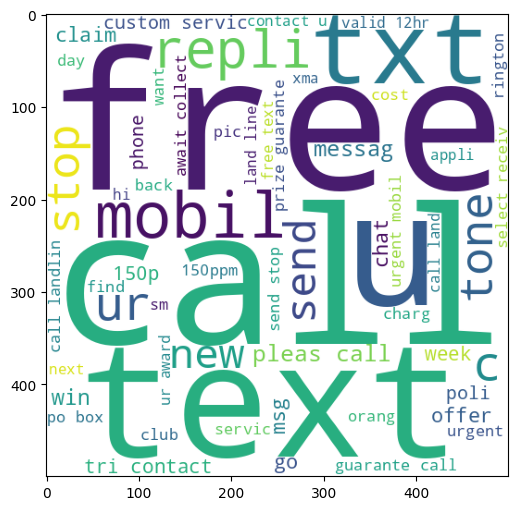

In [184]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [185]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

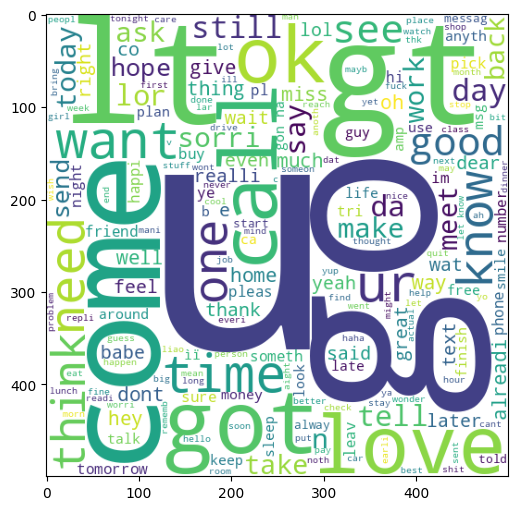

In [186]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [187]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [188]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [189]:
len(spam_corpus)

9939

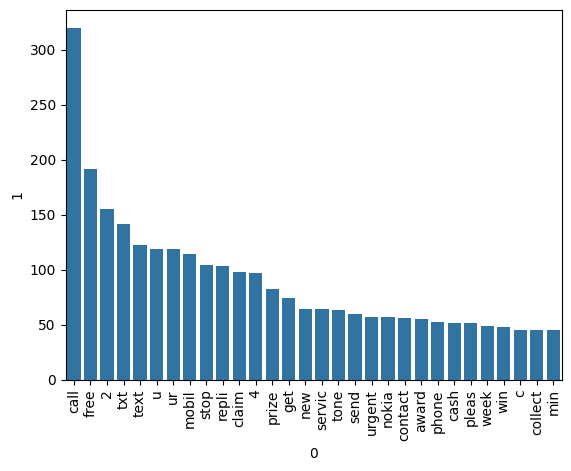

In [190]:
from collections import Counter

df_common = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])
plt.xticks(rotation='vertical')
plt.show()

In [191]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [192]:
len(ham_corpus)

35404

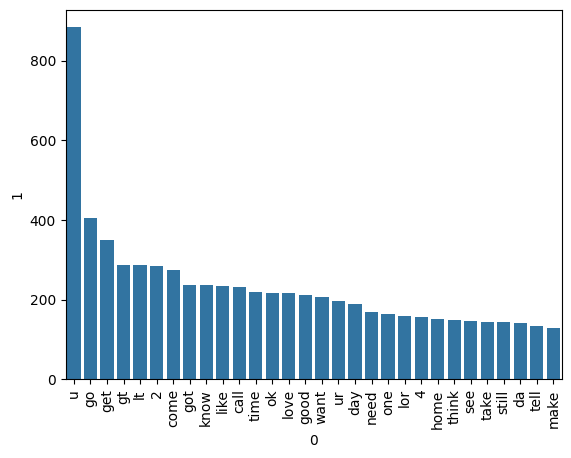

In [193]:
from collections import Counter

df_common = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])
plt.xticks(rotation='vertical')
plt.show()

In [194]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# Model Building

In [195]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [196]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [197]:
X.shape

(5169, 3000)

In [198]:
y = df['target'].values

In [199]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [200]:
from sklearn.model_selection import train_test_split

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [202]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score

In [203]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [204]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)

In [205]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [206]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)

In [207]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [208]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)

In [209]:
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [210]:
# tfidf with mnb

In [211]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [212]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [213]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [214]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    return accuracy,precision,cm,f1

In [215]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354,
 0.9747899159663865,
 array([[893,   3],
        [ 22, 116]]),
 0.9027237354085603)

In [216]:
accuracy_scores = []
precision_scores = []
cm_scores = []
f1_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision,current_cm,current_f1 = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("confusion matrix -",current_cm)
    print("f1 score",current_f1)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    cm_scores.append(current_cm)
    f1_scores.append(current_f1)


For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
confusion matrix - [[893   3]
 [ 22 116]]
f1 score 0.9027237354085603
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
confusion matrix - [[896   0]
 [ 98  40]]
f1 score 0.449438202247191
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
confusion matrix - [[896   0]
 [ 30 108]]
f1 score 0.8780487804878049
For  DT
Accuracy -  0.9303675048355899
Precision -  0.83
confusion matrix - [[879  17]
 [ 55  83]]
f1 score 0.6974789915966386
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
confusion matrix - [[892   4]
 [ 42  96]]
f1 score 0.8067226890756303
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
confusion matrix - [[894   2]
 [ 25 113]]
f1 score 0.8932806324110671
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
confusion matrix - [[880  16]
 [ 65  73]]
f1 score 0.6431718061674009
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542

In [217]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores,'Confusion Matrix':cm_scores,'f1 score':f1_scores}).sort_values('Precision',ascending=False)

In [218]:
performance_df

,Algorithm,Accuracy,Precision,Confusion Matrix,f1 score
1,KN,0.905222,1.000000,"[[896, 0], [98, 40]]",0.449438
2,NB,0.970986,1.000000,"[[896, 0], [30, 108]]",0.878049
5,RF,0.973888,0.982609,"[[894, 2], [25, 113]]",0.893281
0,SVC,0.975822,0.974790,"[[893, 3], [22, 116]]",0.902724
8,ETC,0.974855,0.974576,"[[893, 3], [23, 115]]",0.898438
4,LR,0.955513,0.960000,"[[892, 4], [42, 96]]",0.806723
10,xgb,0.968085,0.948718,"[[890, 6], [27, 111]]",0.870588
9,GBDT,0.950677,0.930693,"[[889, 7], [44, 94]]",0.786611
7,BgC,0.958414,0.868217,"[[879, 17], [26, 112]]",0.838951
3,DT,0.930368,0.830000,"[[879, 17], [55, 83]]",0.697479


In [219]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [222]:
performance_df

,Algorithm,Accuracy,Precision,Confusion Matrix,f1 score
1,KN,0.905222,1.000000,"[[896, 0], [98, 40]]",0.449438
2,NB,0.970986,1.000000,"[[896, 0], [30, 108]]",0.878049
5,RF,0.973888,0.982609,"[[894, 2], [25, 113]]",0.893281
0,SVC,0.975822,0.974790,"[[893, 3], [22, 116]]",0.902724
8,ETC,0.974855,0.974576,"[[893, 3], [23, 115]]",0.898438
4,LR,0.955513,0.960000,"[[892, 4], [42, 96]]",0.806723
10,xgb,0.968085,0.948718,"[[890, 6], [27, 111]]",0.870588
9,GBDT,0.950677,0.930693,"[[889, 7], [44, 94]]",0.786611
7,BgC,0.958414,0.868217,"[[879, 17], [26, 112]]",0.838951
3,DT,0.930368,0.830000,"[[879, 17], [55, 83]]",0.697479


In [224]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [225]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('rfc', rfc)],voting='soft')

In [226]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('rfc',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [227]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("F1 Score",f1_score(y_test,y_pred))

Accuracy 0.9777562862669246
Precision 0.9914529914529915
Confusion Matrix [[895   1]
 [ 22 116]]
F1 Score 0.9098039215686274


In [228]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('rfc', rfc)]
final_estimator=RandomForestClassifier()

In [229]:
from sklearn.ensemble import StackingClassifier

In [230]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [231]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("F1 Score",f1_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 0.9538461538461539
Confusion Matrix [[890   6]
 [ 14 124]]
F1 Score 0.9253731343283582


In [232]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))